In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy.stats as stats

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

# 실행결과 경고메시지 출력 제외
import warnings
warnings.filterwarnings('ignore')


# 데이터 불러오기

In [37]:
oxi_df = pd.read_csv("./B1_반도체/Oxidation.csv", parse_dates=["Datetime"])
inspect_df = pd.read_csv("./B1_반도체/Inspect.csv", parse_dates=["Datetime"])

In [38]:
display(oxi_df.head())
display(inspect_df.head())

,No_Die,Ox_Chamber,process,type,Temp_OXid,Vapor,ppm,Pressure,Oxid_time,thickness,Lot_Num,Wafer_Num,Datetime
0,NOLSM32513132,2,Oxidation,dry,1214.33,O2,26.78,0.30,120,712.98,13,28,2024-07-01
1,NOLSM32513133,2,Oxidation,dry,977.98,O2,30.90,0.14,137,714.41,13,29,2024-07-01
2,NOLSM32513134,2,Oxidation,dry,1175.95,O2,31.11,0.25,116,710.27,13,30,2024-07-01
3,NOLSM32513135,2,Oxidation,dry,933.47,O2,31.20,0.29,143,710.62,13,31,2024-07-01
4,NOLSM32513136,2,Oxidation,wet,1140.60,H2O,31.38,0.20,76,711.70,13,32,2024-07-01


,No_Die,Lot_Num,Wafer_Num,Datetime,Target,Error_message,Wafer_map
0,NOLSM32513132,13,28,2024-07-01,141,none,[[0 0 0 0 0 0 0 0 0 0 1 2 1 1 1 2 0 0 0 0 0 0 ...
1,NOLSM32513133,13,29,2024-07-01,55,none,[[0 0 0 0 0 0 0 0 0 0 2 2 2 2 1 2 0 0 0 0 0 0 ...
2,NOLSM32513134,13,30,2024-07-01,96,none,[[0 0 0 0 0 0 0 0 0 0 1 2 1 1 1 2 0 0 0 0 0 0 ...
3,NOLSM32513135,13,31,2024-07-01,105,none,[[0 0 0 0 0 0 0 0 0 0 2 1 1 1 1 2 0 0 0 0 0 0 ...
4,NOLSM32513136,13,32,2024-07-01,79,none,[[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 ...


In [39]:
merge_df = oxi_df.merge(inspect_df, on = ['No_Die','Lot_Num','Wafer_Num','Datetime'])
merge_df.drop('Wafer_map', axis = 1, inplace = True)
merge_df.head()

,No_Die,Ox_Chamber,process,type,Temp_OXid,Vapor,ppm,Pressure,Oxid_time,thickness,Lot_Num,Wafer_Num,Datetime,Target,Error_message
0,NOLSM32513132,2,Oxidation,dry,1214.33,O2,26.78,0.30,120,712.98,13,28,2024-07-01,141,none
1,NOLSM32513133,2,Oxidation,dry,977.98,O2,30.90,0.14,137,714.41,13,29,2024-07-01,55,none
2,NOLSM32513134,2,Oxidation,dry,1175.95,O2,31.11,0.25,116,710.27,13,30,2024-07-01,96,none
3,NOLSM32513135,2,Oxidation,dry,933.47,O2,31.20,0.29,143,710.62,13,31,2024-07-01,105,none
4,NOLSM32513136,2,Oxidation,wet,1140.60,H2O,31.38,0.20,76,711.70,13,32,2024-07-01,79,none


# 분포 확인

In [40]:
oxi_df['Ox_Chamber'] = oxi_df['Ox_Chamber'].astype(str)
for_dist = oxi_df.drop(columns = ['No_Die','process','Lot_Num', 'Wafer_Num'])
object_x = for_dist.select_dtypes('object').columns.tolist()
numeric_x = for_dist.select_dtypes(include = ['int','float']).columns.tolist()

print(object_x)
print(numeric_x)

['Ox_Chamber', 'type', 'Vapor']
['Temp_OXid', 'ppm', 'Pressure', 'Oxid_time', 'thickness']


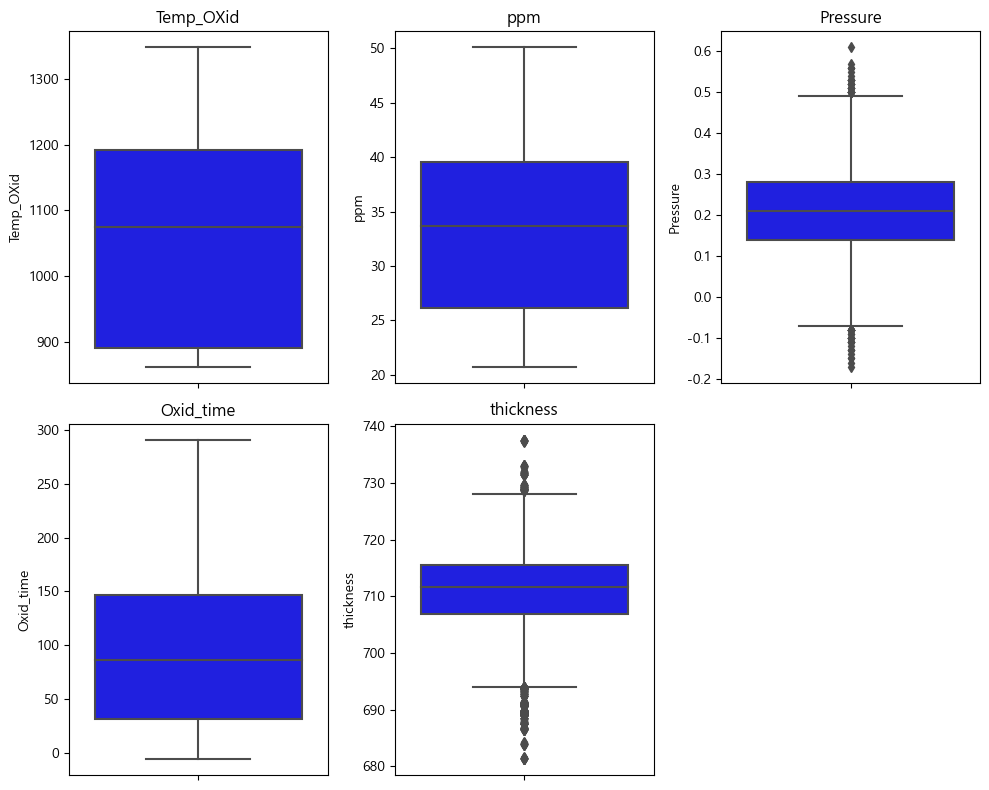

In [49]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 8))  # 크기 조정
axes = axes.flatten()

for i, col in enumerate(numeric_x):
    sns.boxplot(y=oxi_df[col], ax=axes[i], color='blue')
    axes[i].set_title(col)

# 남은 빈 서브플롯 숨기기
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


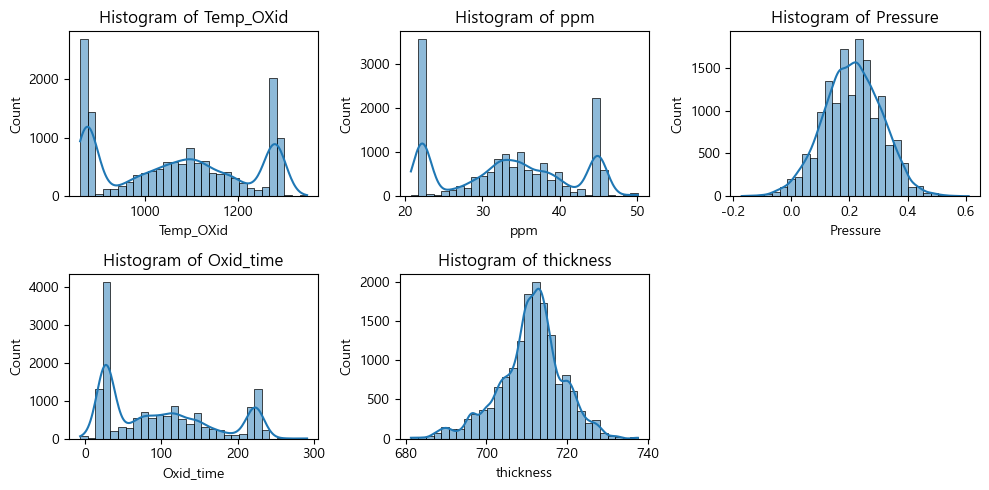

In [47]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))
axes = axes.flatten()

for i, col in enumerate(numeric_x):
    sns.histplot(oxi_df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Histogram of {col}")
# 남은 빈 서브플롯 숨기기
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# object 그래프
fig, axes = plt.subplots(1, 3, figsize=(10,5))

# 올바른 barplot 사용법
sns.barplot(x=oxi_df['type'].value_counts().index, 
            y=oxi_df['type'].value_counts().values, 
            ax=axes[0])
sns.barplot(x=oxi_df['Vapor'].value_counts().index,
            y=oxi_df['Vapor'].value_counts().values,
            ax=axes[1])
sns.barplot(x=oxi_df['Ox_Chamber'].value_counts().index,
            y=oxi_df['Ox_Chamber'].value_counts().values,
            ax=axes[2])
axes[0].set_xlabel("Type")  # X축 레이블 추가
axes[1].set_xlabel("Vapor")  # X축 레이블 추가
axes[2].set_xlabel("Ox_Chamber")  # X축 레이블 추가
plt.show()

# -> dry 방법은 o2, wet 방법은 h2o사용

In [9]:
oxi_df[(oxi_df['type'] == 'dry') & (oxi_df['Vapor'] == 'H2O')]

,No_Die,Ox_Chamber,process,type,Temp_OXid,Vapor,ppm,Pressure,Oxid_time,thickness,Lot_Num,Wafer_Num,Datetime


-> type과 vapor는 같은 값을 가짐( dry - O2, wet - H2O)

# 정규성 검정

In [10]:
from scipy.stats import kstest

def ktest(df, column_name): 
    stat, p = kstest(df[column_name], 'norm')
    print(f"{column_name} Kolmogorov-Smirnov Test: stat={stat:.4f}, p={p:.4f}")

def shapiro(df, column_name):
    stat, p = stats.shapiro(df[column_name])
    print(f"{column_name} Shapiro-Wilk Test: stat={stat:.4f}, p={p:.4f}")

def anderson(df, column_name):
    result = stats.anderson(df[column_name], dist='norm')
    print(column_name)
    print("Anderson-Darling Test:", result.statistic)
    print("Critical Values:", result.critical_values)
    print("Significance Levels:", result.significance_level)
    print()


In [11]:
numeric_x = merge_df.select_dtypes(include = ['float','int'])
for i in numeric_x:
    ktest(merge_df, i)

Ox_Chamber Kolmogorov-Smirnov Test: stat=0.8413, p=0.0000
Temp_OXid Kolmogorov-Smirnov Test: stat=1.0000, p=0.0000
ppm Kolmogorov-Smirnov Test: stat=1.0000, p=0.0000
Pressure Kolmogorov-Smirnov Test: stat=0.4835, p=0.0000
Oxid_time Kolmogorov-Smirnov Test: stat=0.9946, p=0.0000
thickness Kolmogorov-Smirnov Test: stat=1.0000, p=0.0000
Lot_Num Kolmogorov-Smirnov Test: stat=0.9457, p=0.0000
Wafer_Num Kolmogorov-Smirnov Test: stat=0.9611, p=0.0000
Target Kolmogorov-Smirnov Test: stat=0.9988, p=0.0000


In [12]:
for i in numeric_x:
    shapiro(merge_df, i)

Ox_Chamber Shapiro-Wilk Test: stat=0.7938, p=0.0000
Temp_OXid Shapiro-Wilk Test: stat=0.9002, p=0.0000
ppm Shapiro-Wilk Test: stat=0.9181, p=0.0000
Pressure Shapiro-Wilk Test: stat=0.9989, p=0.0000
Oxid_time Shapiro-Wilk Test: stat=0.8796, p=0.0000
thickness Shapiro-Wilk Test: stat=0.9824, p=0.0000
Lot_Num Shapiro-Wilk Test: stat=0.9540, p=0.0000
Wafer_Num Shapiro-Wilk Test: stat=0.9540, p=0.0000
Target Shapiro-Wilk Test: stat=0.8299, p=0.0000


In [13]:
for i in numeric_x:
    anderson(merge_df, i)

Ox_Chamber
Anderson-Darling Test: 1257.2721099413648
Critical Values: [0.576 0.656 0.787 0.918 1.092]
Significance Levels: [15.  10.   5.   2.5  1. ]

Temp_OXid
Anderson-Darling Test: 437.2990971342879
Critical Values: [0.576 0.656 0.787 0.918 1.092]
Significance Levels: [15.  10.   5.   2.5  1. ]

ppm
Anderson-Darling Test: 349.33436902164794
Critical Values: [0.576 0.656 0.787 0.918 1.092]
Significance Levels: [15.  10.   5.   2.5  1. ]

Pressure
Anderson-Darling Test: 7.15292573620718
Critical Values: [0.576 0.656 0.787 0.918 1.092]
Significance Levels: [15.  10.   5.   2.5  1. ]

Oxid_time
Anderson-Darling Test: 634.3246936057676
Critical Values: [0.576 0.656 0.787 0.918 1.092]
Significance Levels: [15.  10.   5.   2.5  1. ]

thickness
Anderson-Darling Test: 92.00033306457772
Critical Values: [0.576 0.656 0.787 0.918 1.092]
Significance Levels: [15.  10.   5.   2.5  1. ]

Lot_Num
Anderson-Darling Test: 175.80939266695714
Critical Values: [0.576 0.656 0.787 0.918 1.092]
Significance

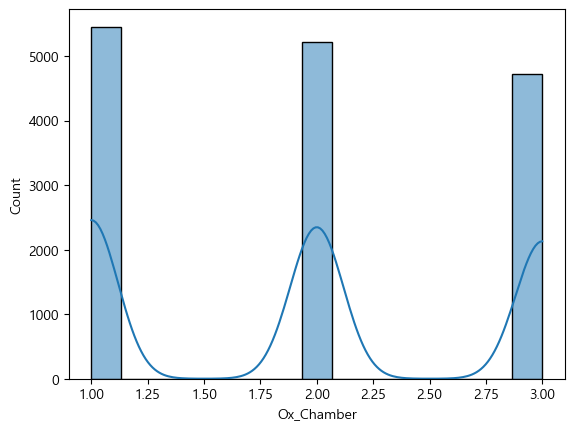

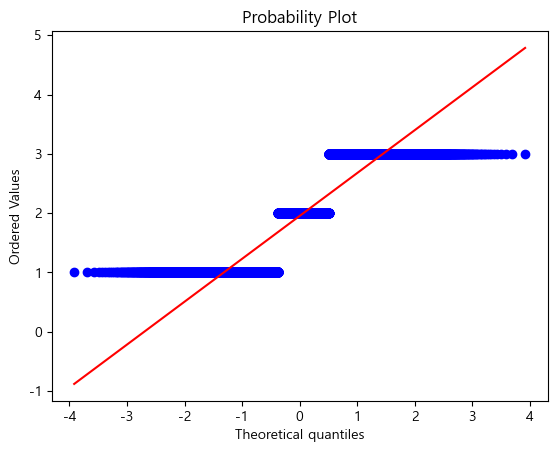

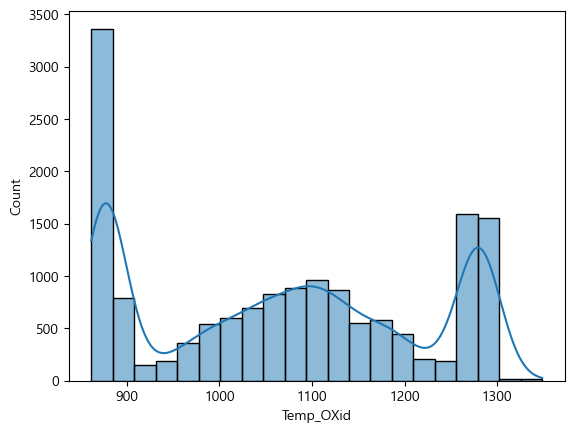

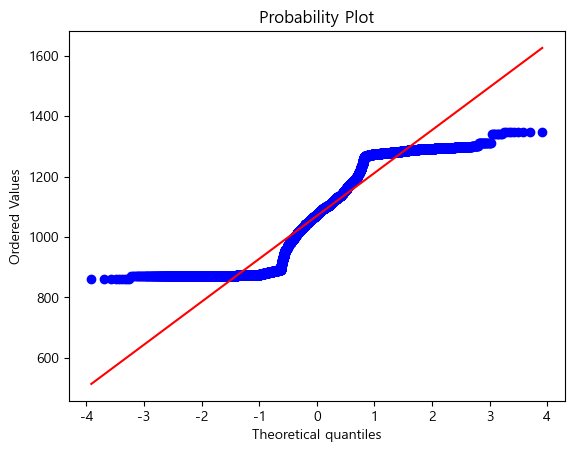

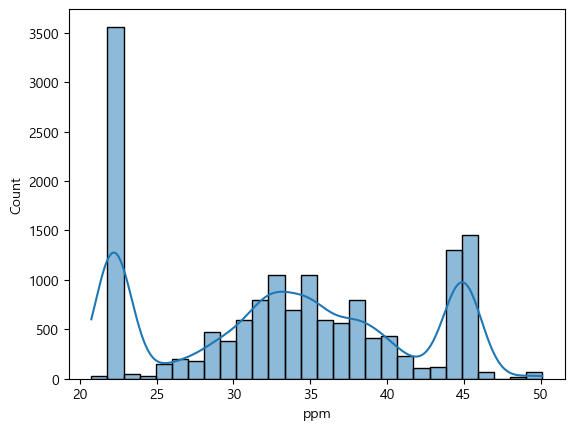

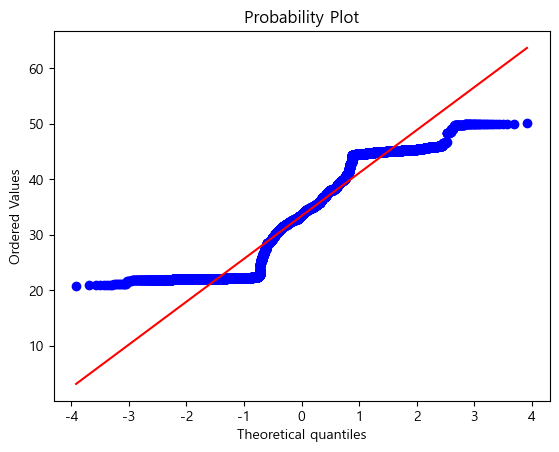

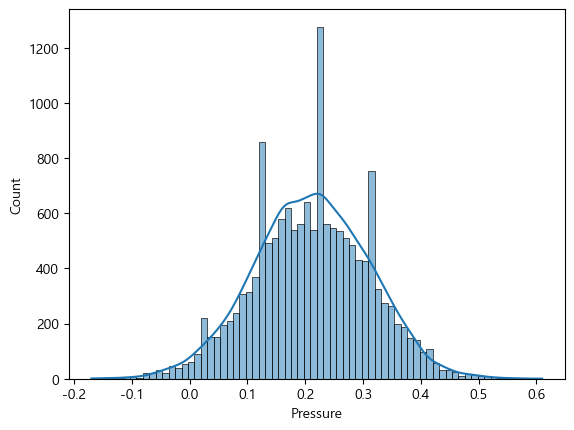

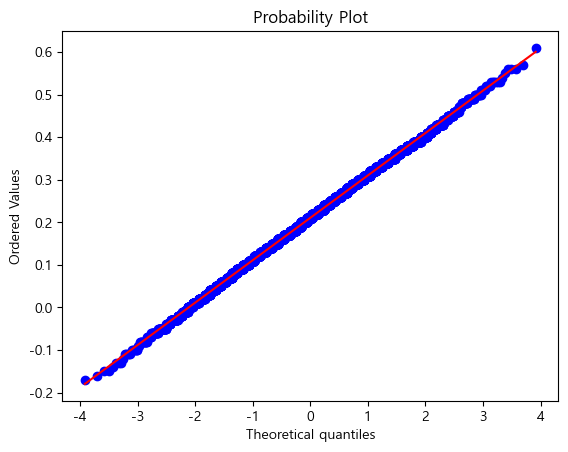

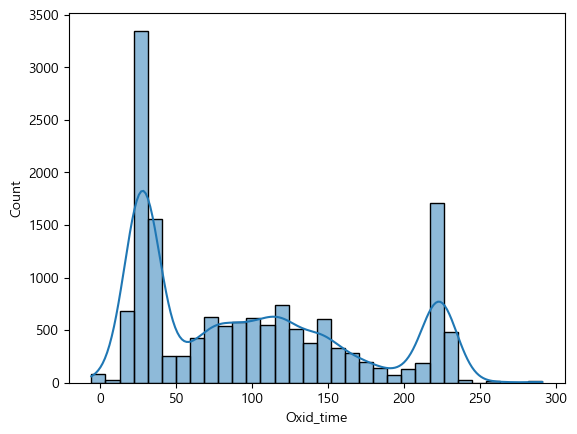

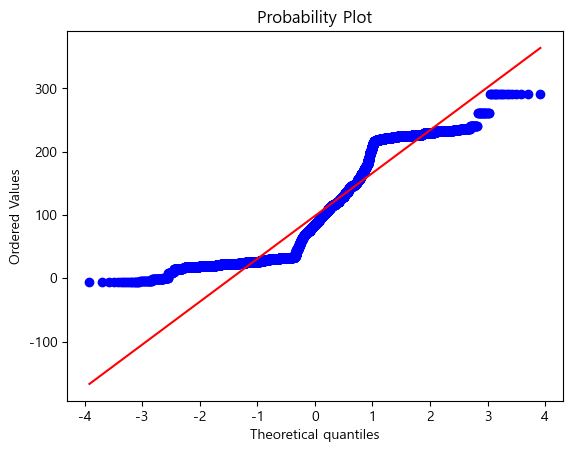

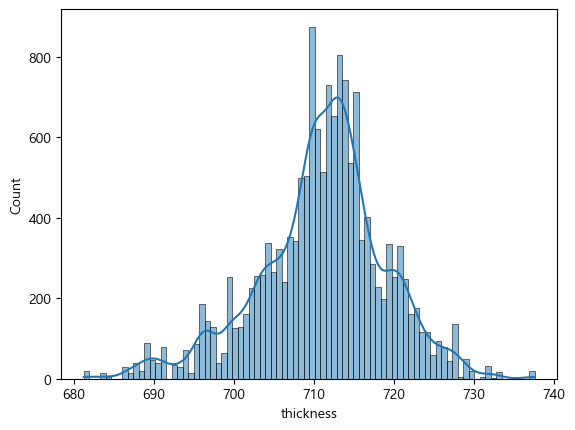

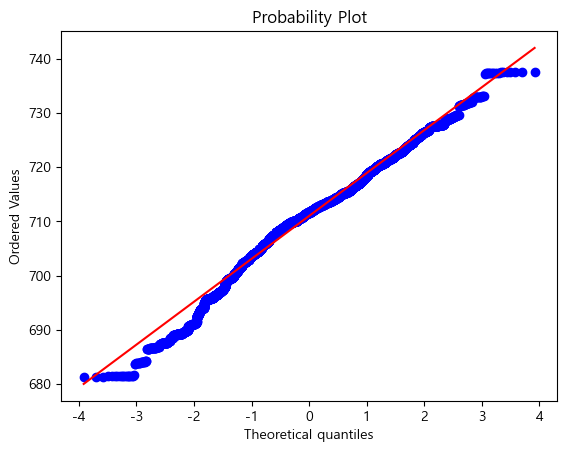

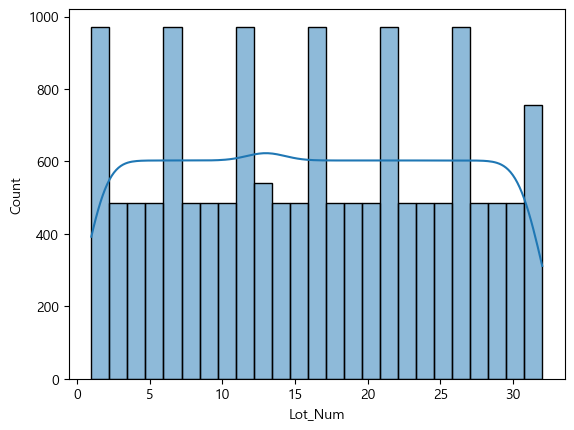

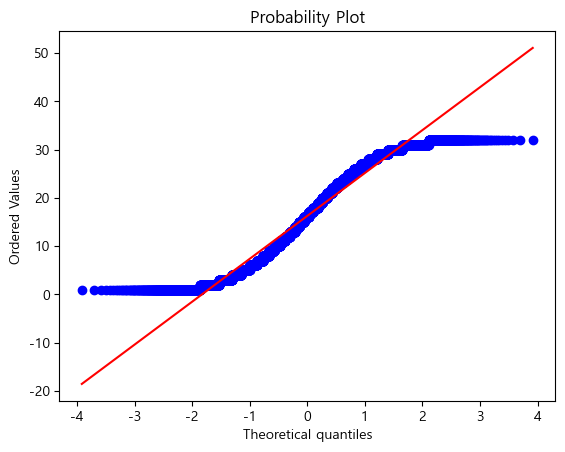

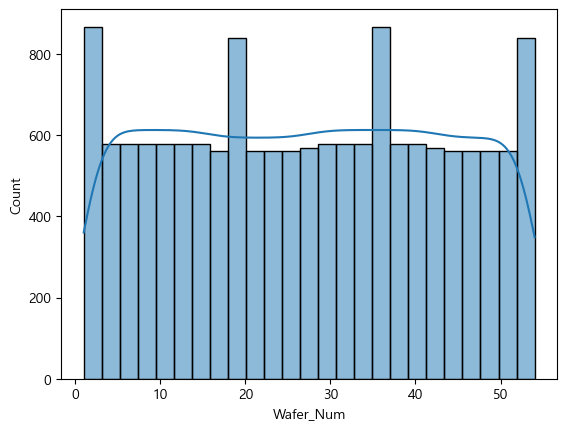

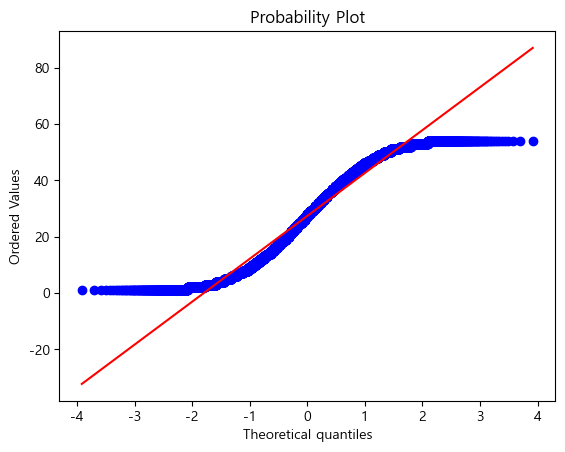

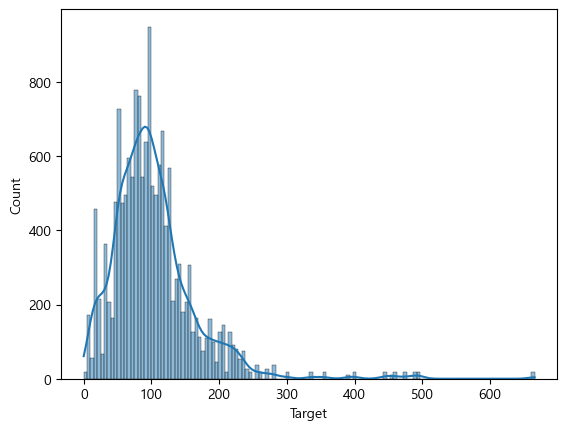

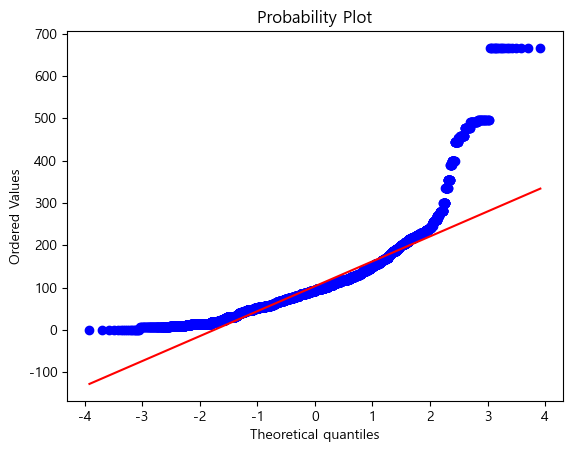

In [14]:
# 히스토그램 (확률 밀도 함수)
def draw_graph(df, column_name):
    sns.histplot(df[column_name], kde=True)  # kde=True: 커널 밀도 추정
    plt.show()
    
    # QQ 플롯 (정규 분포와 비교)
    stats.probplot(df[column_name], dist="norm", plot=plt)
    plt.show()

for i in numeric_x:
    draw_graph(merge_df, i)

# mann-whitney 검정

In [15]:
## 어떤 방법으로 보아도 정규성을 만족하지 못하므로, mann-whitney 검정을 사용

In [16]:
def y_label(value):
    if value > 195:
        return 1
    else:
        return 0
merge_df['y_label'] = merge_df['Target'].apply(y_label)
merge_df.head()

,No_Die,Ox_Chamber,process,type,Temp_OXid,Vapor,ppm,Pressure,Oxid_time,thickness,Lot_Num,Wafer_Num,Datetime,Target,Error_message,y_label
0,NOLSM32513132,2,Oxidation,dry,1214.33,O2,26.78,0.30,120,712.98,13,28,2024-07-01,141,none,0
1,NOLSM32513133,2,Oxidation,dry,977.98,O2,30.90,0.14,137,714.41,13,29,2024-07-01,55,none,0
2,NOLSM32513134,2,Oxidation,dry,1175.95,O2,31.11,0.25,116,710.27,13,30,2024-07-01,96,none,0
3,NOLSM32513135,2,Oxidation,dry,933.47,O2,31.20,0.29,143,710.62,13,31,2024-07-01,105,none,0
4,NOLSM32513136,2,Oxidation,wet,1140.60,H2O,31.38,0.20,76,711.70,13,32,2024-07-01,79,none,0


In [17]:
pos_df = merge_df[merge_df['y_label'] == 1]
neg_df = merge_df[merge_df['y_label'] == 0]

In [22]:
def mann_whitney_test(pos_df, neg_df, n_deactive, column_name):
    np.random.seed(42)  # 랜덤 시드 고정
    sampled_good = np.random.choice(neg_df[column_name], n_deactive, replace=False)
    sampled_bad = np.random.choice(pos_df[column_name], n_deactive, replace=False)

    # Mann-Whitney U Test 수행
    stat, p = stats.mannwhitneyu(sampled_good, sampled_bad, alternative='two-sided')
    print(f"Sampled Mann-Whitney U Test: stat={stat:.4f}, p-value={p:.4f}")

    graph_df = pd.DataFrame({
        column_name: np.concatenate([sampled_good, sampled_bad]),
        "Category": ["양품"] * n_deactive + ["불량품"] * n_deactive
    })
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
    
    sns.boxplot(x="Category", y=column_name, data=graph_df, palette=["blue", "red"], ax=axes[0])
    axes[0].set_title(column_name +" Boxplot")
    
    sns.kdeplot(sampled_good, fill=True, color="blue", label="양품", ax=axes[1])
    sns.kdeplot(sampled_bad, fill=True, color="red", label="불량품", ax=axes[1])
    axes[1].set_title(column_name + " KDE Plot")
    axes[1].legend()
    
    axes[2].hist(sampled_good, bins=20, alpha=0.6, color="blue", label="양품")
    axes[2].hist(sampled_bad, bins=20, alpha=0.6, color="red", label="불량품")
    axes[2].set_title(column_name +" Histogram")
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

Sampled Mann-Whitney U Test: stat=152007.0000, p-value=0.0000


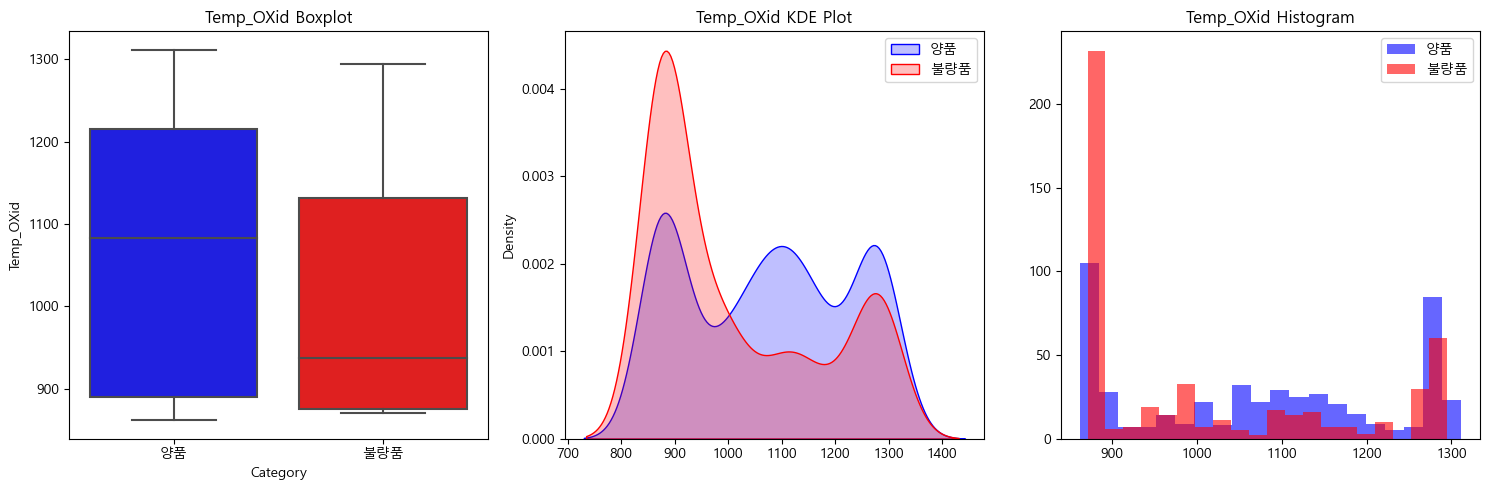

In [23]:
mann_whitney_test(pos_df, neg_df, 500, 'Temp_OXid')

Sampled Mann-Whitney U Test: stat=139282.0000, p-value=0.0018


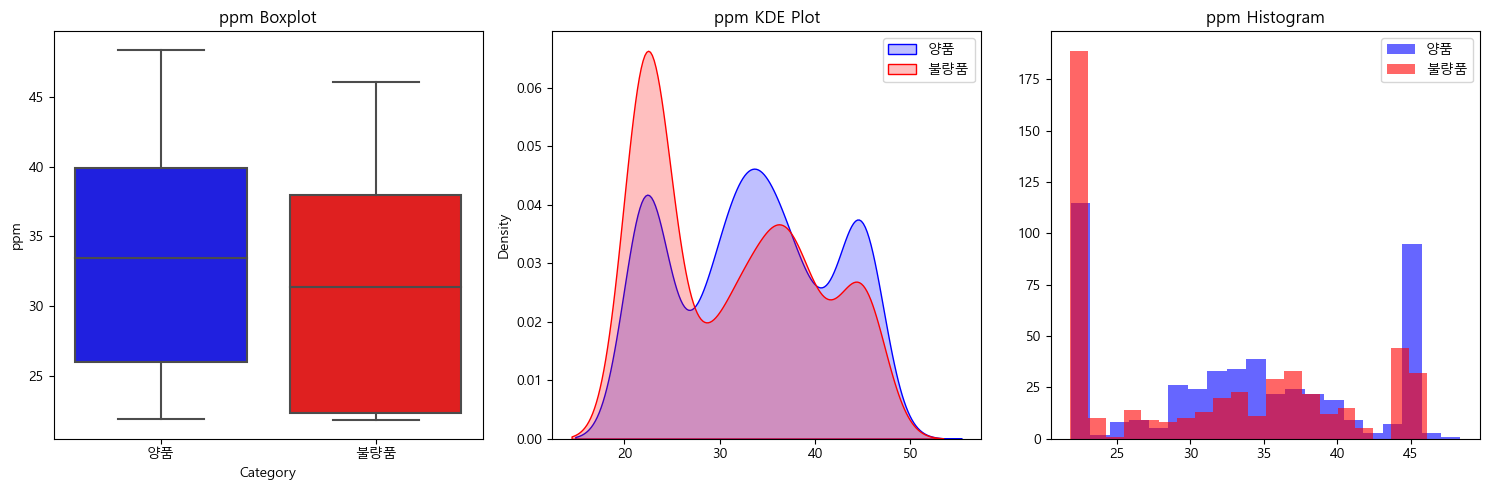

In [24]:
mann_whitney_test(pos_df, neg_df, 500, 'ppm')

Sampled Mann-Whitney U Test: stat=117804.5000, p-value=0.1149


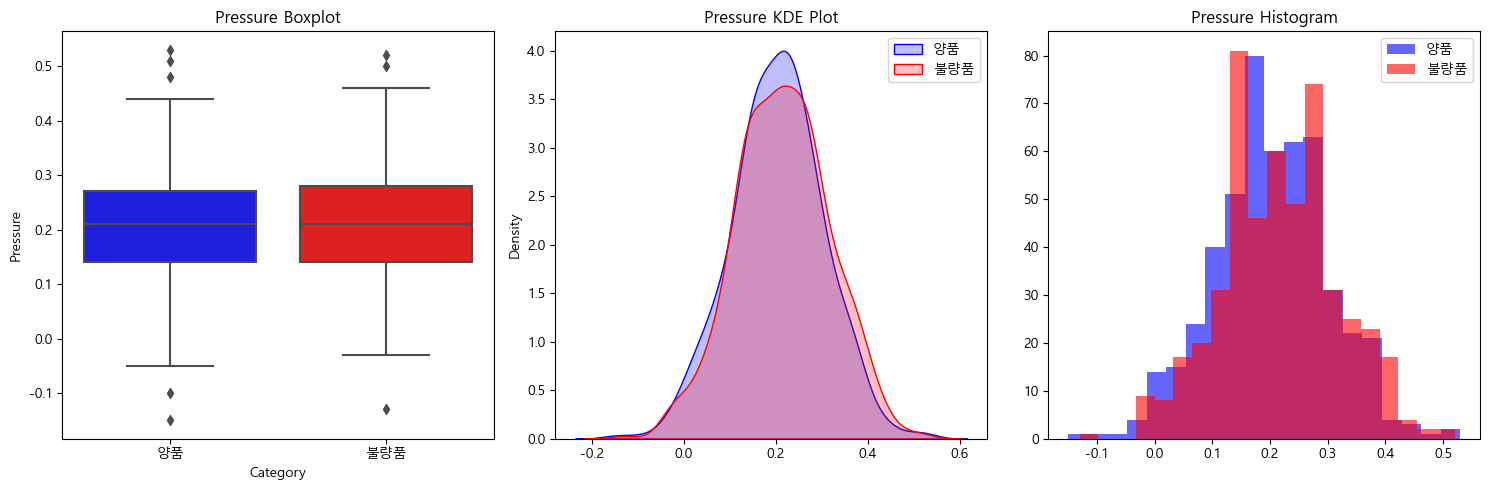

In [25]:
mann_whitney_test(pos_df, neg_df, 500, 'Pressure')

Sampled Mann-Whitney U Test: stat=83012.5000, p-value=0.0000


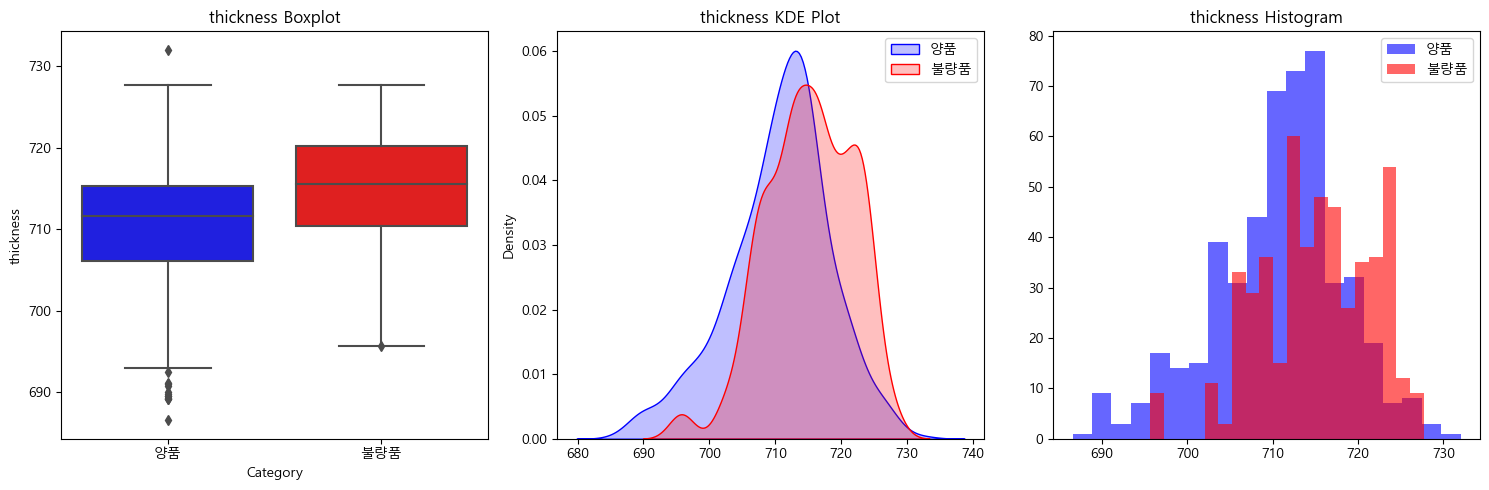

In [26]:
mann_whitney_test(pos_df, neg_df, 500, 'thickness')

# 카이제곱 검정

In [27]:
## chamber와 type에 따라 달라지는 것은 카이제곱 사용

In [28]:
# 1. chamber

pos_chamber_1 = pos_df[pos_df['Ox_Chamber']== 1]
pos_chamber_2 = pos_df[pos_df['Ox_Chamber']== 2]
pos_chamber_3 = pos_df[pos_df['Ox_Chamber']== 3]

neg_chamber_1 = neg_df[neg_df['Ox_Chamber']== 1]
neg_chamber_2 = neg_df[neg_df['Ox_Chamber']== 2]
neg_chamber_3 = neg_df[neg_df['Ox_Chamber']== 3]

print("chamber 1: 양품", len(neg_chamber_1), "불량품:", len(pos_chamber_1))
print("chamber 2: 양품", len(neg_chamber_2), "불량품:", len(pos_chamber_2))
print("chamber 3: 양품", len(neg_chamber_3), "불량품:", len(pos_chamber_3))

chamber 1: 양품 5121 불량품: 333
chamber 2: 양품 4804 불량품: 407
chamber 3: 양품 4374 불량품: 351


In [29]:
# 각 챔버별 양품과 불량품 수
data = np.array([[5121, 4804, 4374],  # 양품
                 [333, 407, 351]])   # 불량품

# 카이제곱 검정 수행
chi2, p, dof, expected = stats.chi2_contingency(data)

# 결과 출력
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies:\n{expected}")


Chi-Square Statistic: 12.9524
P-value: 0.0015
Degrees of Freedom: 2
Expected Frequencies:
[[5067.36491228 4841.59122807 4390.04385965]
 [ 386.63508772  369.40877193  334.95614035]]


In [30]:
# 1. type

pos_type_1 = pos_df[pos_df['type']== 'wet']
pos_type_2 = pos_df[pos_df['type']== 'dry']

neg_type_1 = neg_df[neg_df['type']== 'wet']
neg_type_2 = neg_df[neg_df['type']== 'dry']


print("wet: 양품", len(neg_type_1), "불량품:", len(pos_type_1))
print("dry: 양품", len(neg_type_2), "불량품:", len(pos_type_2))

wet: 양품 6167 불량품: 279
dry: 양품 8132 불량품: 812


In [31]:
# 각 챔버별 양품과 불량품 수
data = np.array([[6167, 8132],  # 양품
                 [279, 812]])   # 불량품

# 카이제곱 검정 수행
chi2, p, dof, expected = stats.chi2_contingency(data)

# 결과 출력
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies:\n{expected}")


Chi-Square Statistic: 127.6307
P-value: 0.0000
Degrees of Freedom: 1
Expected Frequencies:
[[5989.04184535 8309.95815465]
 [ 456.95815465  634.04184535]]


# 데이터 전처리

In [62]:
print(len(merge_df))
merge_df.describe()

15390


,Ox_Chamber,Temp_OXid,ppm,Pressure,Oxid_time,thickness,Lot_Num,Wafer_Num,Target,y_label
count,15390.000000,15390.000000,15390.000000,15390.000000,15390.000000,15390.000000,15390.000000,15390.000000,15390.000000,15390.00000
mean,1.952632,1069.561949,33.433087,0.210669,98.422482,711.009857,16.270175,27.394737,103.080767,0.07089
std,0.811913,149.623690,8.065673,0.099710,72.247199,7.993167,9.097856,15.582558,64.651090,0.25665
min,1.000000,861.790000,20.750000,-0.170000,-6.000000,681.270000,1.000000,1.000000,0.000000,0.00000
25%,1.000000,889.670000,26.180000,0.140000,31.000000,706.910000,8.000000,14.000000,64.000000,0.00000
50%,2.000000,1075.295000,33.650000,0.210000,86.000000,711.680000,16.000000,27.500000,94.000000,0.00000
75%,3.000000,1192.032500,39.527500,0.280000,147.000000,715.497500,24.000000,41.000000,126.000000,0.00000
max,3.000000,1348.620000,50.090000,0.610000,291.000000,737.600000,32.000000,54.000000,666.000000,1.00000


In [64]:
pressure_outlier_index = merge_df[merge_df['Pressure'] < 0].index
rm_po_df = merge_df.drop(pressure_outlier_index)
print(len(rm_po_df))
rm_po_df.describe()

15134


,Ox_Chamber,Temp_OXid,ppm,Pressure,Oxid_time,thickness,Lot_Num,Wafer_Num,Target,y_label
count,15134.000000,15134.000000,15134.000000,15134.000000,15134.000000,15134.000000,15134.000000,15134.000000,15134.000000,15134.000000
mean,1.952954,1069.638303,33.439317,0.214935,98.266883,711.028703,16.276464,27.387604,103.129642,0.071098
std,0.812108,149.714519,8.070976,0.094866,72.256875,7.980031,9.102757,15.569784,64.766966,0.256997
min,1.000000,861.790000,20.750000,-0.000000,-6.000000,681.270000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,889.650000,26.180000,0.150000,31.000000,706.930000,8.000000,14.000000,64.000000,0.000000
50%,2.000000,1075.460000,33.650000,0.210000,85.000000,711.690000,16.000000,27.500000,94.000000,0.000000
75%,3.000000,1192.410000,39.550000,0.280000,147.000000,715.510000,24.000000,41.000000,126.000000,0.000000
max,3.000000,1348.620000,50.090000,0.610000,291.000000,737.600000,32.000000,54.000000,666.000000,1.000000


In [65]:
time_outlier_index = merge_df[merge_df['Oxid_time'] <= 0].index
rm_to_df = rm_po_df.drop(time_outlier_index)
print(len(rm_to_df))
rm_to_df.describe()

15051


,Ox_Chamber,Temp_OXid,ppm,Pressure,Oxid_time,thickness,Lot_Num,Wafer_Num,Target,y_label
count,15051.000000,15051.000000,15051.000000,15051.000000,15051.000000,15051.000000,15051.000000,15051.000000,15051.000000,15051.000000
mean,1.952761,1069.505265,33.426839,0.215017,98.825792,711.104752,16.290944,27.455385,103.096406,0.070892
std,0.812094,149.848943,8.081811,0.094842,72.061497,7.897913,9.101644,15.554745,64.732104,0.256653
min,1.000000,861.790000,20.750000,-0.000000,8.000000,681.270000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,889.300000,26.095000,0.150000,31.000000,707.020000,8.000000,14.000000,64.000000,0.000000
50%,2.000000,1075.370000,33.620000,0.210000,86.000000,711.720000,16.000000,28.000000,94.000000,0.000000
75%,3.000000,1192.535000,39.550000,0.280000,147.000000,715.530000,24.000000,41.000000,126.000000,0.000000
max,3.000000,1348.620000,50.090000,0.610000,291.000000,737.600000,32.000000,54.000000,666.000000,1.000000


In [66]:
rm_to_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15051 entries, 0 to 15389
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   No_Die         15051 non-null  object        
 1   Ox_Chamber     15051 non-null  int64         
 2   process        15051 non-null  object        
 3   type           15051 non-null  object        
 4   Temp_OXid      15051 non-null  float64       
 5   Vapor          15051 non-null  object        
 6   ppm            15051 non-null  float64       
 7   Pressure       15051 non-null  float64       
 8   Oxid_time      15051 non-null  int64         
 9   thickness      15051 non-null  float64       
 10  Lot_Num        15051 non-null  int64         
 11  Wafer_Num      15051 non-null  int64         
 12  Datetime       15051 non-null  datetime64[ns]
 13  Target         15051 non-null  int64         
 14  Error_message  15051 non-null  object        
 15  y_label        1505

In [68]:
result_df = rm_to_df.drop(columns = ['process', 'Lot_Num', 'Wafer_Num' ,'Vapor', 'Datetime', 'y_label', 'Target', 'Error_message'])
result_df.head()

,No_Die,Ox_Chamber,type,Temp_OXid,ppm,Pressure,Oxid_time,thickness
0,NOLSM32513132,2,dry,1214.33,26.78,0.30,120,712.98
1,NOLSM32513133,2,dry,977.98,30.90,0.14,137,714.41
2,NOLSM32513134,2,dry,1175.95,31.11,0.25,116,710.27
3,NOLSM32513135,2,dry,933.47,31.20,0.29,143,710.62
4,NOLSM32513136,2,wet,1140.60,31.38,0.20,76,711.70


In [70]:
result_df.to_csv("./after_oxidation.csv", index=False)